
### Problem Statement

Employee attrition is a major challenge for organizations because high employee turnover can affect productivity, increase recruitment costs, and impact overall business performance.

The objective of this project is to analyze employee data and identify the key factors influencing employee attrition. Using data analysis and machine learning techniques, the project aims to help HR teams understand attrition patterns and support better employee retention strategies.



In [85]:

# BASIC LIBRARIES

import pandas as pd
import numpy as np

# VISUALIZATION LIBRARIES

import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESSING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


# MODEL EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
    )

In [86]:
df = pd.read_csv("HR_Attrition.csv") # Data Loading

In [87]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [88]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [89]:
df.shape

(1470, 35)

In [90]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [92]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [93]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Missing Values Observation

The dataset contains no missing or null values. This indicates that the employee records are complete and no additional missing value treatment was required before analysis and model building.

In [94]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Attrition Encoding

The target column `Attrition` was converted into numerical format for model training:

- 1 → Yes (Employee left the company)
- 0 → No (Employee stayed in the company)

In [95]:
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Attrition Rate Observation

The attrition analysis showed that approximately 83.88% of employees stayed in the company, while 16.12% of employees left the organization. This indicates that employee attrition cases are fewer compared to non-attrition cases, making the dataset slightly imbalanced.

In [96]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 26
Categorical Columns: 9


In [97]:
numerical_cols # Numerical Columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [98]:
categorical_cols # categorical Columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

#### Observation:
The dataset is imbalanced because employees who stayed are much higher than employees who left.

In [99]:
df.drop(['EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2


In [100]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [101]:
df['Attrition'].unique()

array([1, 0])

In [102]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [103]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Male', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Direct

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to identify patterns and trends related to employee attrition. Different factors such as department, salary, overtime, work-life balance, job role, and years at the company were analyzed to understand why employees leave the organization.

In [104]:
eda_df = pd.read_csv("HR_Attrition.csv")

In [105]:
eda_df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

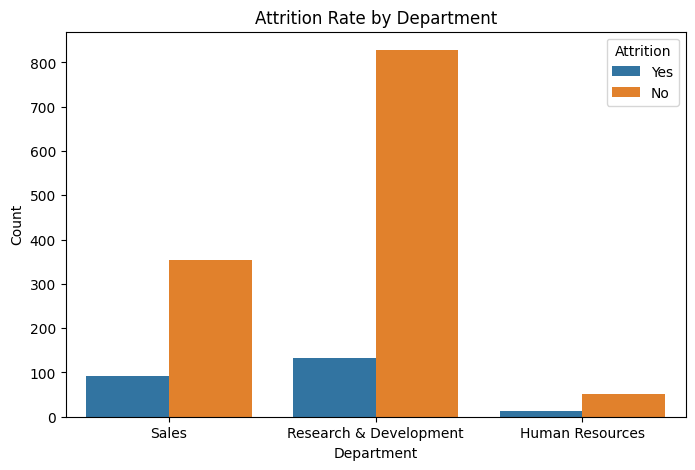

In [106]:
plt.figure(figsize=(8,5))

sns.countplot(x='Department', hue='Attrition', data=eda_df)

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Count')

plt.show()

### Insight

The Sales department showed comparatively higher employee attrition than other departments, indicating a greater employee turnover risk in sales-related roles.

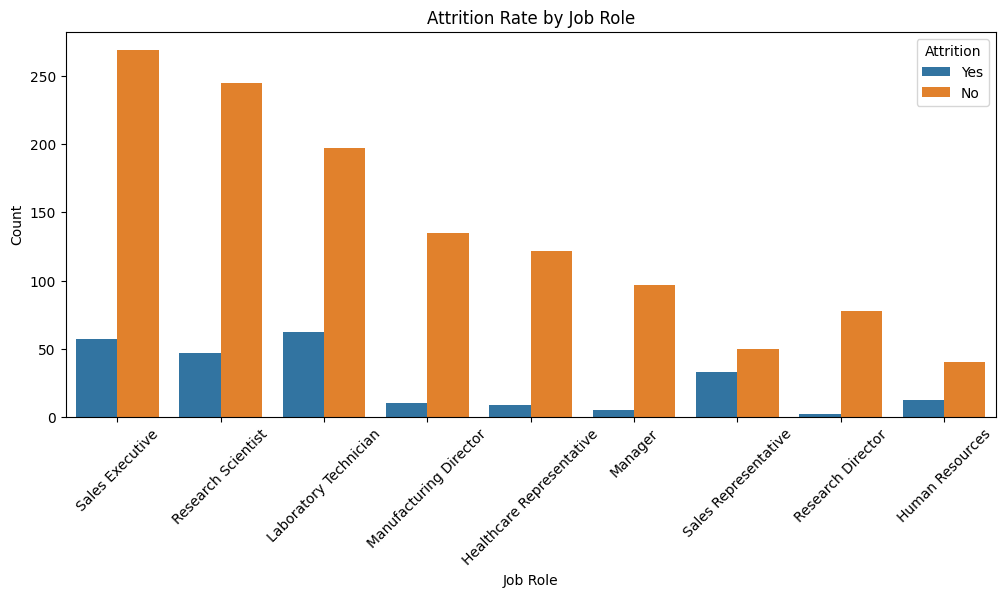

In [107]:
plt.figure(figsize=(12,5))

sns.countplot(x='JobRole', hue='Attrition', data=eda_df)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

### Insight

Sales Representatives and Laboratory Technicians experienced higher attrition rates compared to other job roles, suggesting the need for better retention strategies in these positions.

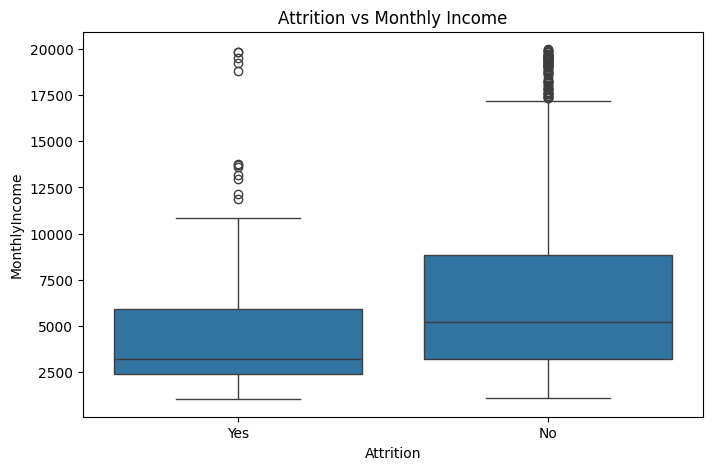

In [108]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=eda_df)

plt.title('Attrition vs Monthly Income')

plt.show()

### Insight

Employees with lower monthly income were more likely to leave the company, indicating that compensation may influence employee retention.

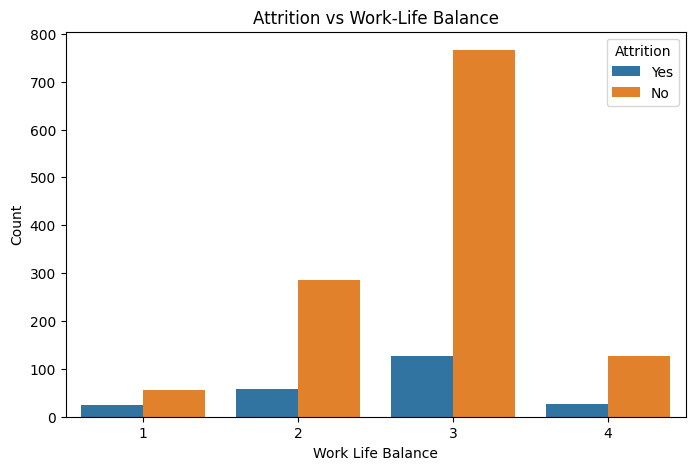

In [109]:
plt.figure(figsize=(8,5))

sns.countplot(x='WorkLifeBalance', hue='Attrition', data=eda_df)

plt.title('Attrition vs Work-Life Balance')
plt.xlabel('Work Life Balance')
plt.ylabel('Count')

plt.show()

### Insight

Employees with lower work-life balance ratings showed higher attrition trends, suggesting that employee well-being plays an important role in retention.

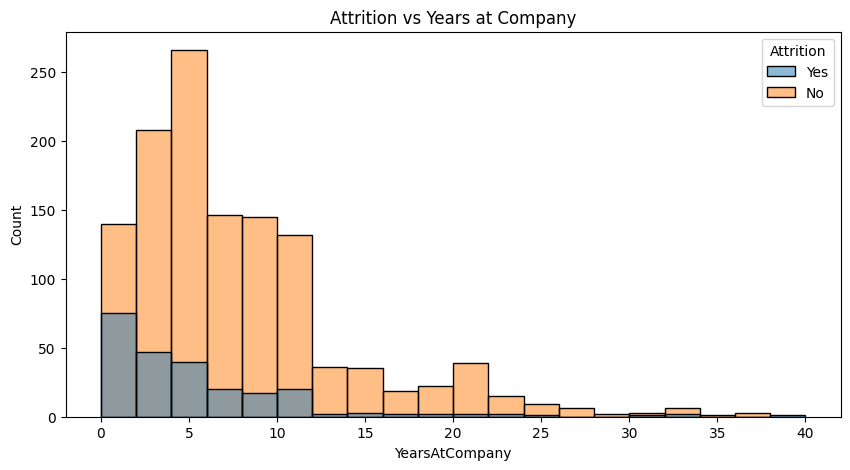

In [110]:
plt.figure(figsize=(10,5))

sns.histplot(data=eda_df,
             x='YearsAtCompany',
             hue='Attrition',
             bins=20)

plt.title('Attrition vs Years at Company')

plt.show()

### Insight

Most employee attrition occurred during the early years of employment, indicating that new employees may require stronger engagement and support programs.

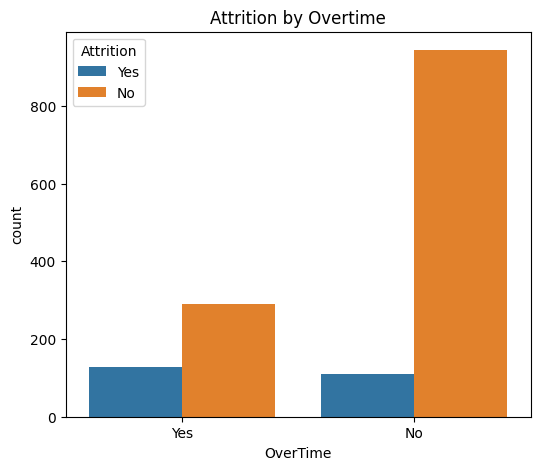

In [111]:
plt.figure(figsize=(6,5))

sns.countplot(x='OverTime', hue='Attrition', data=eda_df)

plt.title('Attrition by Overtime')

plt.show()

### Insight

Employees working overtime were more likely to leave the company compared to employees not working overtime, showing a possible impact of workload and stress on attrition.

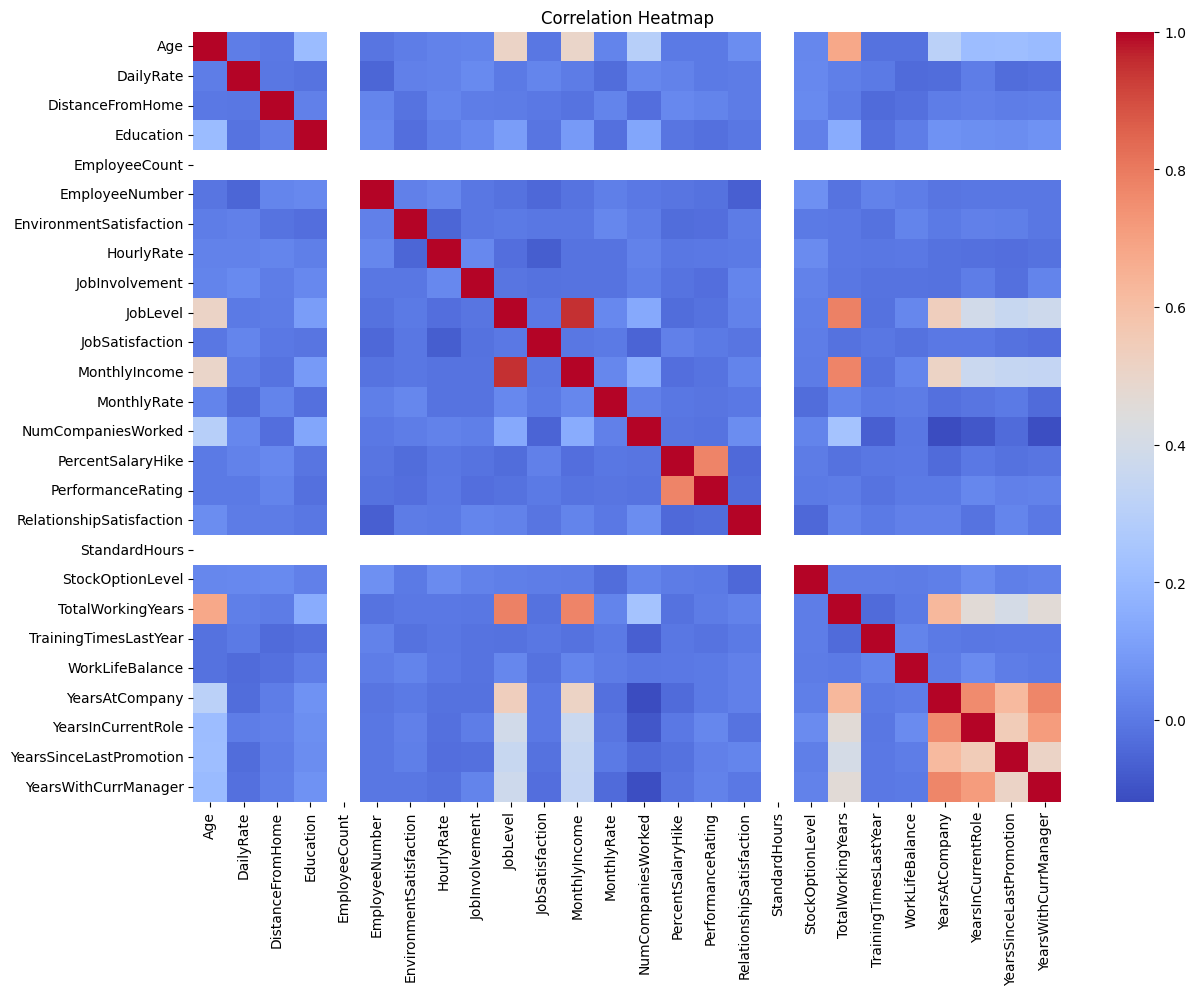

In [112]:
plt.figure(figsize=(14,10))

sns.heatmap(eda_df.corr(numeric_only=True),
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Insight

The correlation analysis showed that multiple employee-related factors are connected with attrition, indicating that employee turnover is influenced by a combination of workplace conditions rather than a single factor.

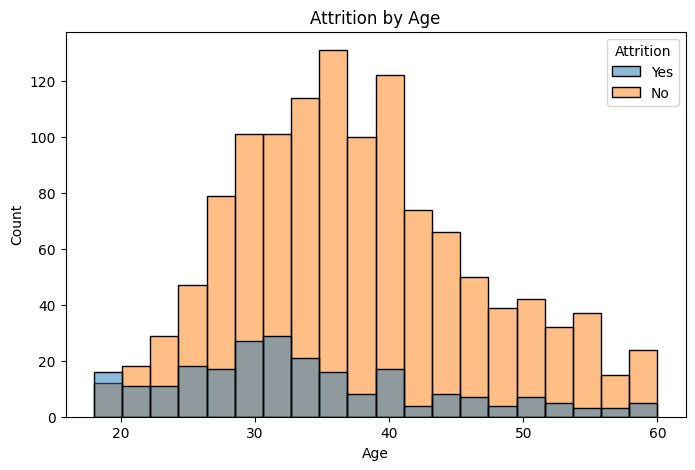

In [113]:
plt.figure(figsize=(8,5))

sns.histplot(data=eda_df,
             x='Age',
             hue='Attrition',
             bins=20)

plt.title('Attrition by Age')

plt.show()

### Insight

Younger employees showed relatively higher attrition compared to older employees, suggesting that early-career employees may change jobs more frequently.

In [114]:
eda_df['JobSatisfaction'] = eda_df['JobSatisfaction'].replace({
    1:'Low',
    2:'Medium',
    3:'High',
    4:'Very High'
})

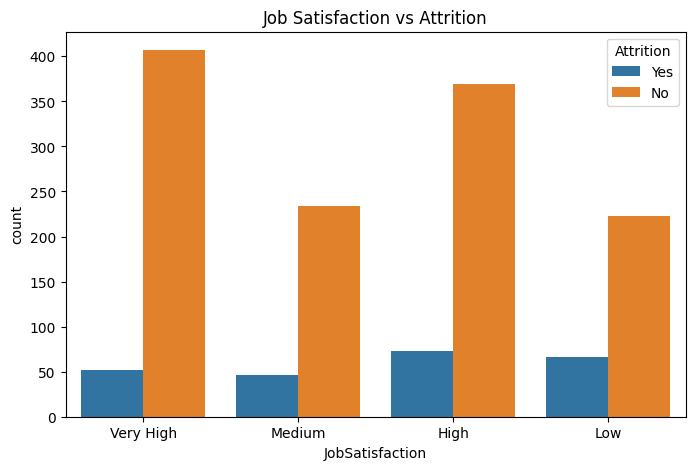

In [115]:
plt.figure(figsize=(8,5))

sns.countplot(x='JobSatisfaction',
              hue='Attrition',
              data=eda_df)

plt.title('Job Satisfaction vs Attrition')

plt.show()

### Insight

Employees with lower job satisfaction ratings showed higher attrition trends, highlighting the importance of employee satisfaction in workforce retention.

In [116]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [118]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [119]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [120]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.717687074829932
Precision: 0.25555555555555554
Recall: 0.5897435897435898
F1 Score: 0.35658914728682173
ROC-AUC: 0.6634992458521871


In [121]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [122]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8809523809523809
Precision: 0.8333333333333334
Recall: 0.1282051282051282
F1 Score: 0.2222222222222222
ROC-AUC: 0.5621417797888386


- The Random Forest model achieved high overall prediction accuracy, but it was less effective in identifying employees who were actually likely to leave the company. This indicates that while the model performed well for overall predictions, detecting attrition cases remains a challenging business problem due to the smaller number of employees leaving compared to those staying.

In [123]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [124]:
print("Gradient Boosting")

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.8673469387755102
Precision: 0.5
Recall: 0.1794871794871795
F1 Score: 0.2641509433962264
ROC-AUC: 0.5760180995475113


In [125]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



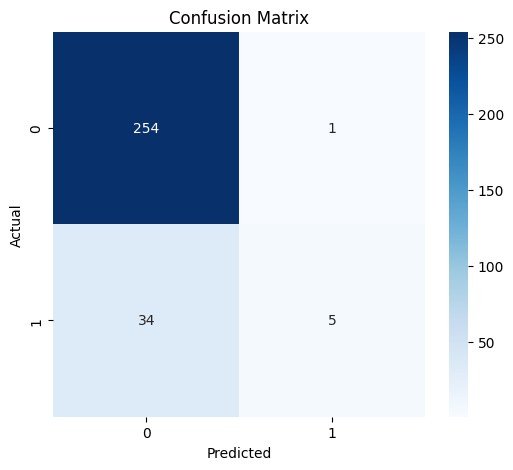

In [126]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Insight

The prediction model was able to correctly identify a large number of employees who stayed in the company, while also identifying a portion of employees likely to leave.

In [127]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance',
                                    ascending=False)

importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.074995
44,OverTime_Yes,0.073391
0,Age,0.054089
20,YearsAtCompany,0.048177
16,StockOptionLevel,0.045816
17,TotalWorkingYears,0.045564
11,MonthlyRate,0.045333
1,DailyRate,0.042982
8,JobLevel,0.039462
6,HourlyRate,0.038309


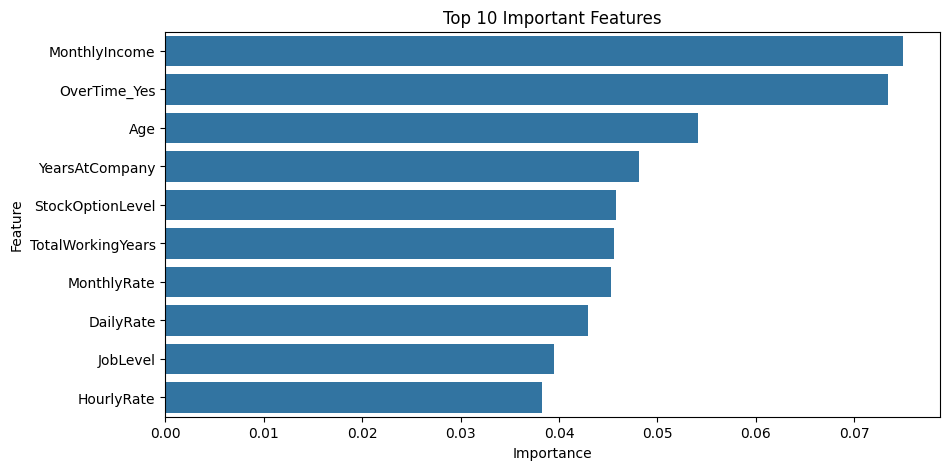

In [128]:
top10 = importance.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x='Importance',
            y='Feature',
            data=top10)

plt.title('Top 10 Important Features')

plt.show()

### Insight

The feature importance analysis identified overtime, monthly income, work-life balance, and years at the company as some of the most influential factors affecting employee attrition.

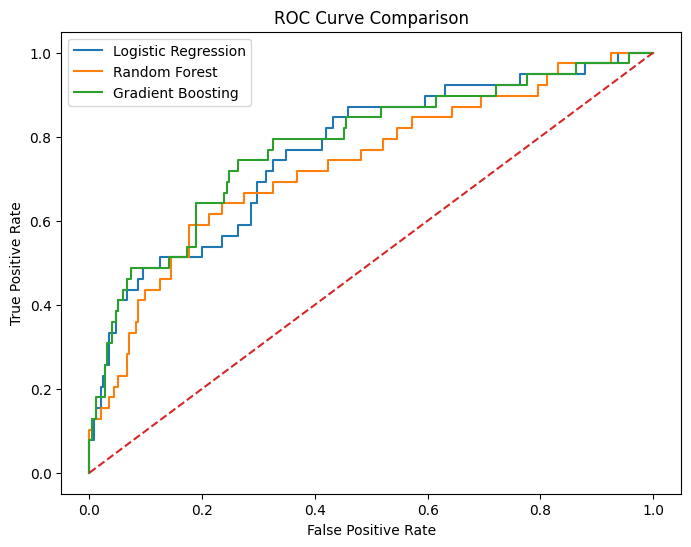

In [129]:
from sklearn.metrics import roc_curve

lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot(gb_fpr, gb_tpr, label='Gradient Boosting')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

### Insight

The ROC curve comparison showed that different models performed differently in identifying employee attrition patterns, helping compare their overall prediction capability.

# Key Business Insights

1. Employees working overtime showed a significantly higher tendency to leave the company compared to employees who did not work overtime.

2. Employees with lower monthly income were more likely to leave, indicating that compensation plays an important role in employee retention.

3. Sales Representatives and Laboratory Technicians experienced higher attrition rates compared to other job roles, suggesting these departments may require additional HR attention.

4. Most employee resignations occurred during the early years of employment, showing the importance of employee engagement and onboarding programs.

5. Poor work-life balance and lower job satisfaction ratings were strongly associated with higher employee attrition.

6. The analysis suggests that employee attrition is influenced by multiple workplace factors and not salary alone.


### Conclusion

This project analyzed employee attrition data to identify the major reasons why employees leave a company. Different machine learning approaches were used to predict attrition patterns and understand employee behavior.

The analysis showed that overtime, lower income, poor work-life balance, and lower job satisfaction were some of the strongest factors linked to employee attrition. Employees in certain job roles also experienced higher turnover compared to others.

These findings can help HR teams take proactive steps such as improving work-life balance policies, increasing employee engagement, and focusing retention efforts on high-risk employee groups. By using data-driven insights, companies can reduce employee turnover and improve overall workplace satisfaction.
